# 📊 Customer Churn Analysis
**Project:** Telco Customer Churn Analysis  
**Author:** [Nama Kamu]  
**Date:** [Tanggal]  
**Dataset:** IBM Telco Customer Churn (Kaggle)

---

## 🎯 Business Problem
Sebuah perusahaan telekomunikasi mengalami churn rate yang tinggi dalam 6 bulan terakhir.
Tim manajemen ingin memahami:
1. **Siapa** customer yang paling berisiko churn?
2. **Faktor apa** yang paling berpengaruh terhadap churn?
3. **Strategi retention** apa yang paling efektif?

## 📐 Success Metrics
- Identifikasi minimum 3 faktor utama penyebab churn
- Segmentasi customer berdasarkan risiko churn
- Rekomendasi bisnis yang actionable dan terukur

## ⚙️ Setup & Installation

In [1]:
# Install packages (jalankan sekali di Colab)
# !pip install -q kaggle plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
COLORS = {'churn': '#E24B4A', 'retain': '#1D9E75', 'neutral': '#378ADD'}

print('✅ Setup complete')

✅ Setup complete


## 📥 1. Data Acquisition

In [2]:
# OPTION A: Download dari Kaggle (butuh kaggle.json)
# from google.colab import files
# files.upload()  # upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d blastchar/telco-customer-churn --unzip

# OPTION B: Load langsung via URL (paling simple untuk Colab)
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df_raw = pd.read_csv(url)

print(f'✅ Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

✅ Dataset loaded: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 🧹 2. Data Cleaning & Preparation

In [3]:
df = df_raw.copy()

# --- Cek overview awal ---
print('=== DATA TYPES ===')
print(df.dtypes)
print(f'\n=== MISSING VALUES ===')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\n=== DUPLICATES === {df.duplicated().sum()} rows')

=== DATA TYPES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== MISSING VALUES ===
Series([], dtype: int64)

=== DUPLICATES === 0 rows


In [4]:
# --- Fix TotalCharges (sering kebaca string) ---
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Investigasi missing TotalCharges
missing_tc = df[df['TotalCharges'].isna()]
print(f'Missing TotalCharges: {len(missing_tc)} rows')
print('Distribusi tenure pada baris missing:')
print(missing_tc['tenure'].value_counts())

# Reasoning: missing karena tenure=0 (customer baru, belum ada tagihan)
# → isi dengan 0, bukan drop
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print('\n✅ TotalCharges: converted to numeric, missing values filled with 0 (new customers)')

Missing TotalCharges: 11 rows
Distribusi tenure pada baris missing:
tenure
0    11
Name: count, dtype: int64

✅ TotalCharges: converted to numeric, missing values filled with 0 (new customers)


In [5]:
# --- Encode target variable ---
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

# --- Feature engineering: Tenure Group ---
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months'],
    include_lowest=True
)

# --- Feature engineering: Charges per month ratio ---
df['ChargesRatio'] = df['TotalCharges'] / (df['tenure'] + 1)  # +1 hindari divide by zero

print(f'✅ Feature engineering complete')
print(f'Target distribution:')
print(df['Churn'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

✅ Feature engineering complete
Target distribution:
Churn
No     73.5%
Yes    26.5%
Name: proportion, dtype: object


## 🔍 3. Exploratory Data Analysis (EDA)

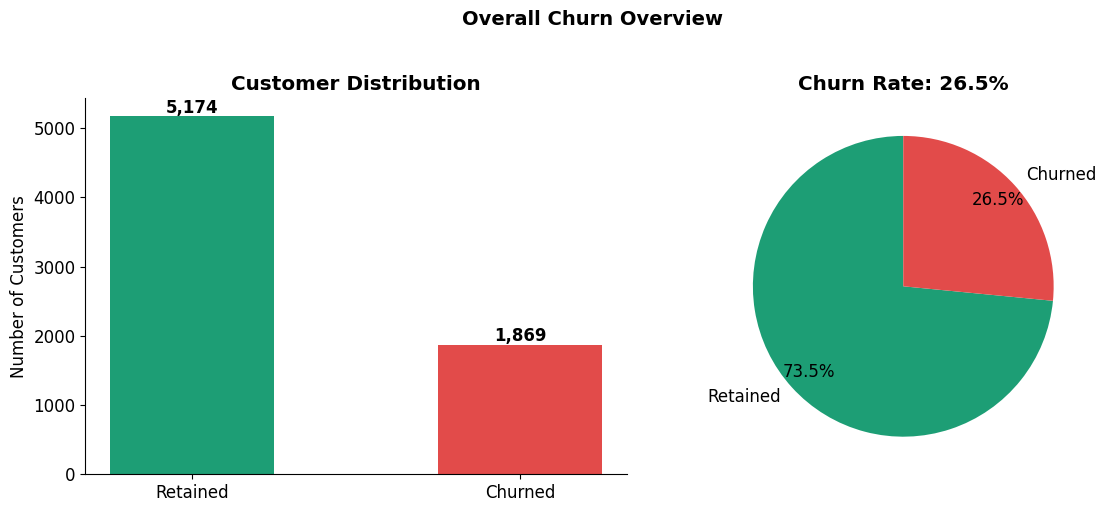


📌 INSIGHT: 26.5% customer meninggalkan layanan.
   Dengan asumsi ARPU $65/bulan, potensi revenue loss = $121,485/bulan.


In [7]:
# === A. CHURN RATE OVERALL ===
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn_Binary'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = ax[0].bar(['Retained', 'Churned'], churn_counts.values,
                  color=[COLORS['retain'], COLORS['churn']], width=0.5)
for bar, val in zip(bars, churn_counts.values):
    ax[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
               f'{val:,}', ha='center', fontweight='bold')
ax[0].set_title('Customer Distribution', fontweight='bold')
ax[0].set_ylabel('Number of Customers')

# Pie chart
ax[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
          colors=[COLORS['retain'], COLORS['churn']],
          autopct='%1.1f%%', startangle=90, pctdistance=0.85)
ax[1].set_title(f'Churn Rate: {churn_rate:.1f}%', fontweight='bold')

plt.suptitle('Overall Churn Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 INSIGHT: {churn_rate:.1f}% customer meninggalkan layanan.')
print(f'   Dengan asumsi ARPU $65/bulan, potensi revenue loss = ${churn_counts["Yes"] * 65:,.0f}/bulan.')

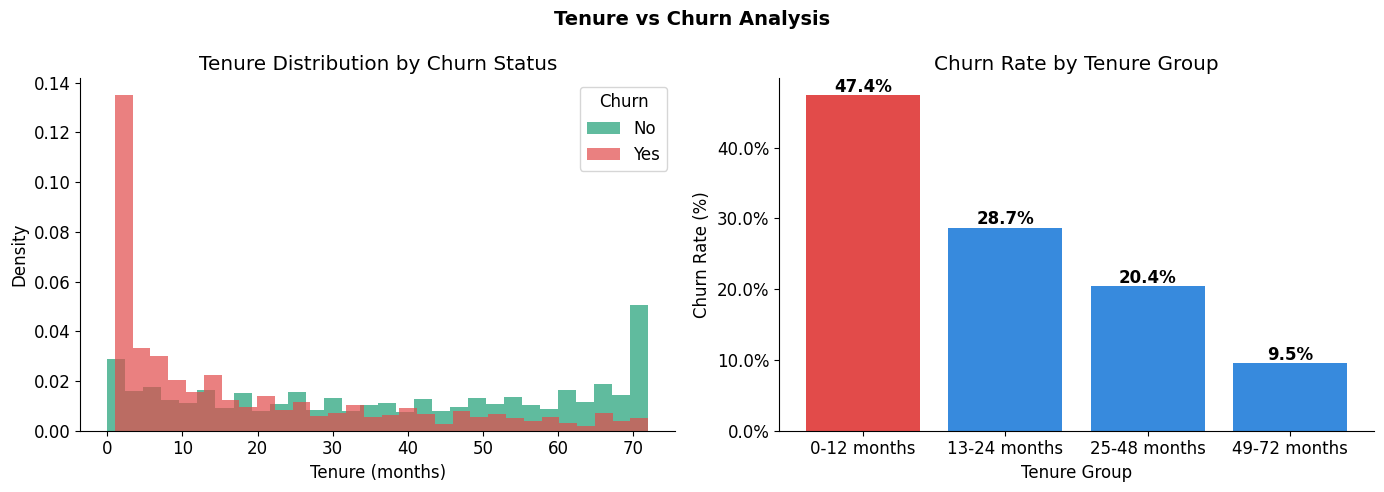


📌 INSIGHT: 47.4 % customer dengan tenure 0-12 bulan churn — tertinggi dari semua grup.
   Implication: Program onboarding 90 hari pertama harus diprioritaskan.


In [9]:
# === B. TENURE vs CHURN ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by churn
for label, color in [('No', COLORS['retain']), ('Yes', COLORS['churn'])]:
    axes[0].hist(df[df['Churn'] == label]['tenure'],
                 bins=30, alpha=0.7, color=color, label=label, density=True)
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Density')
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].legend(title='Churn')

# Churn rate by tenure group
tenure_churn = df.groupby('TenureGroup', observed=True)['Churn_Binary'].mean().mul(100).reset_index()
bars = axes[1].bar(tenure_churn['TenureGroup'], tenure_churn['Churn_Binary'],
                    color=[COLORS['churn'] if v > 30 else COLORS['neutral']
                           for v in tenure_churn['Churn_Binary']])
for bar, val in zip(bars, tenure_churn['Churn_Binary']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_xlabel('Tenure Group')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Tenure Group')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Tenure vs Churn Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 INSIGHT:', tenure_churn.iloc[0]['Churn_Binary'].__round__(1),
      '% customer dengan tenure 0-12 bulan churn — tertinggi dari semua grup.')
print('   Implication: Program onboarding 90 hari pertama harus diprioritaskan.')

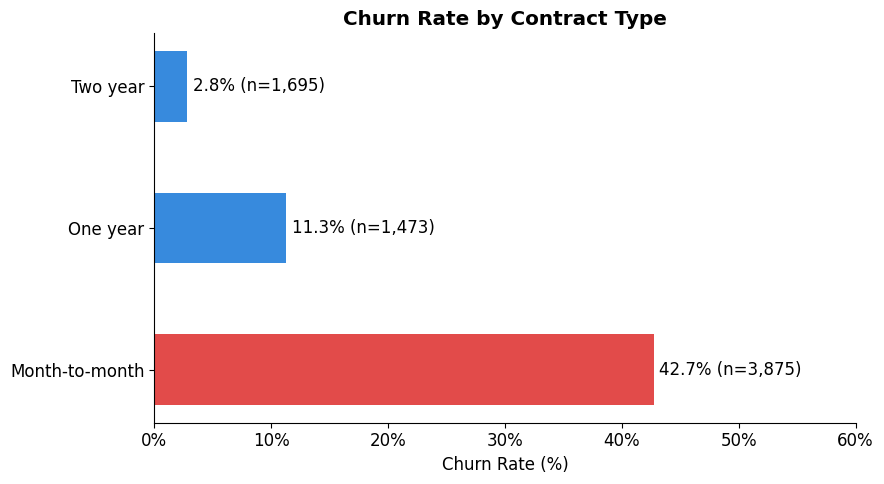


📌 INSIGHT: Customer month-to-month memiliki churn rate jauh lebih tinggi.
   Action: Buat incentive untuk upgrade ke annual contract (diskon, bonus data, dll.)


In [10]:
# === C. CONTRACT TYPE vs CHURN ===
contract_churn = df.groupby('Contract')['Churn_Binary'].agg(['mean', 'count']).reset_index()
contract_churn['churn_rate'] = contract_churn['mean'] * 100
contract_churn = contract_churn.sort_values('churn_rate', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_contract = [COLORS['churn'] if r > 30 else COLORS['neutral']
                   for r in contract_churn['churn_rate']]
bars = ax.barh(contract_churn['Contract'], contract_churn['churn_rate'],
               color=colors_contract, height=0.5)
for bar, (_, row) in zip(bars, contract_churn.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{row["churn_rate"]:.1f}% (n={row["count"]:,})', va='center')
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by Contract Type', fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 60)
plt.tight_layout()
plt.savefig('03_contract_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 INSIGHT: Customer month-to-month memiliki churn rate jauh lebih tinggi.')
print('   Action: Buat incentive untuk upgrade ke annual contract (diskon, bonus data, dll.)')

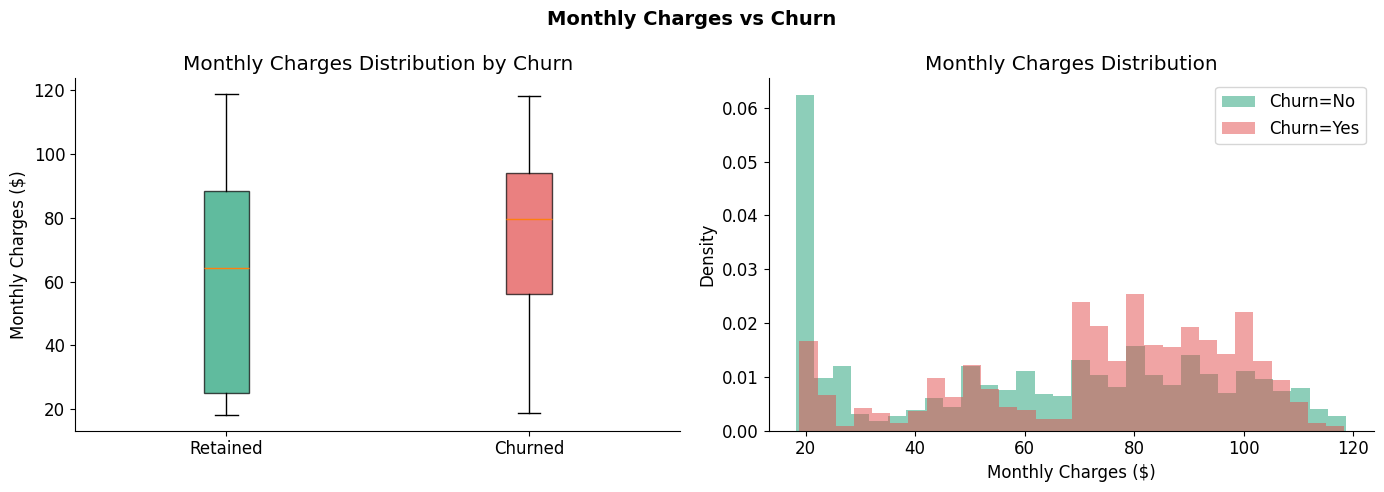


📌 INSIGHT:
   Median charges churned: $80/bulan
   Median charges retained: $64/bulan
   Penting: Harga tinggi = churn? Belum tentu. Cek faktor lain (kontrak, layanan).


In [11]:
# === D. MONTHLY CHARGES vs CHURN ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
churn_yes = df[df['Churn'] == 'Yes']['MonthlyCharges']
churn_no = df[df['Churn'] == 'No']['MonthlyCharges']
bp = axes[0].boxplot([churn_no, churn_yes], labels=['Retained', 'Churned'],
                     patch_artist=True)
bp['boxes'][0].set_facecolor(COLORS['retain'])
bp['boxes'][1].set_facecolor(COLORS['churn'])
for patch in bp['boxes']:
    patch.set_alpha(0.7)
axes[0].set_ylabel('Monthly Charges ($)')
axes[0].set_title('Monthly Charges Distribution by Churn')

# KDE plot
for label, color in [('No', COLORS['retain']), ('Yes', COLORS['churn'])]:
    data = df[df['Churn'] == label]['MonthlyCharges']
    axes[1].hist(data, bins=30, density=True, alpha=0.5, color=color, label=f'Churn={label}')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Density')
axes[1].set_title('Monthly Charges Distribution')
axes[1].legend()

plt.suptitle('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_charges_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 INSIGHT:')
print(f'   Median charges churned: ${churn_yes.median():.0f}/bulan')
print(f'   Median charges retained: ${churn_no.median():.0f}/bulan')
print(f'   Penting: Harga tinggi = churn? Belum tentu. Cek faktor lain (kontrak, layanan).')

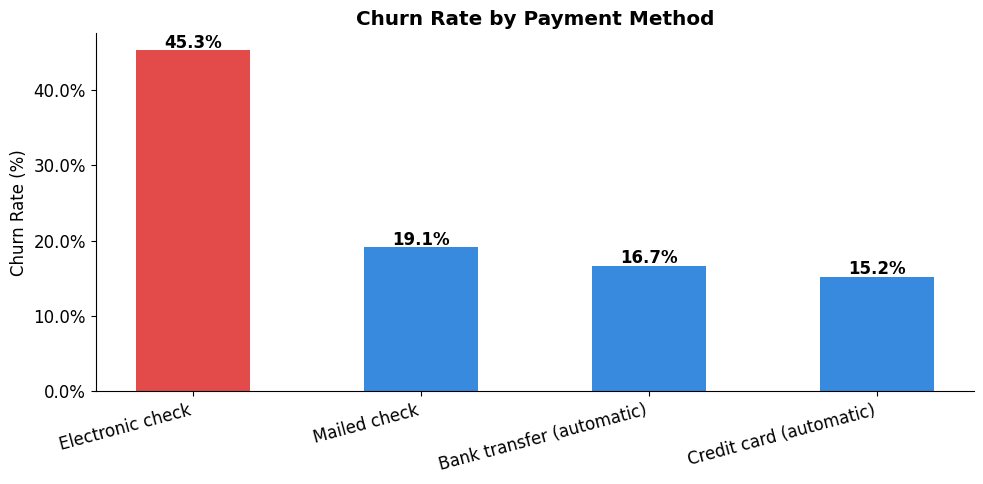


📌 INSIGHT: Electronic check memiliki churn rate tertinggi.
   Possible reason: segment ini lebih transaksional, less committed.
   Action: Dorong auto-payment untuk mengurangi friction dan meningkatkan retention.


In [12]:
# === E. PAYMENT METHOD vs CHURN ===
payment_churn = df.groupby('PaymentMethod')['Churn_Binary'].mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_pm = [COLORS['churn'] if v > 30 else COLORS['neutral'] for v in payment_churn.values]
bars = ax.bar(payment_churn.index, payment_churn.values, color=colors_pm, width=0.5)
for bar, val in zip(bars, payment_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Payment Method', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticklabels(payment_churn.index, rotation=15, ha='right')
plt.tight_layout()
plt.savefig('05_payment_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 INSIGHT: Electronic check memiliki churn rate tertinggi.')
print('   Possible reason: segment ini lebih transaksional, less committed.')
print('   Action: Dorong auto-payment untuk mengurangi friction dan meningkatkan retention.')

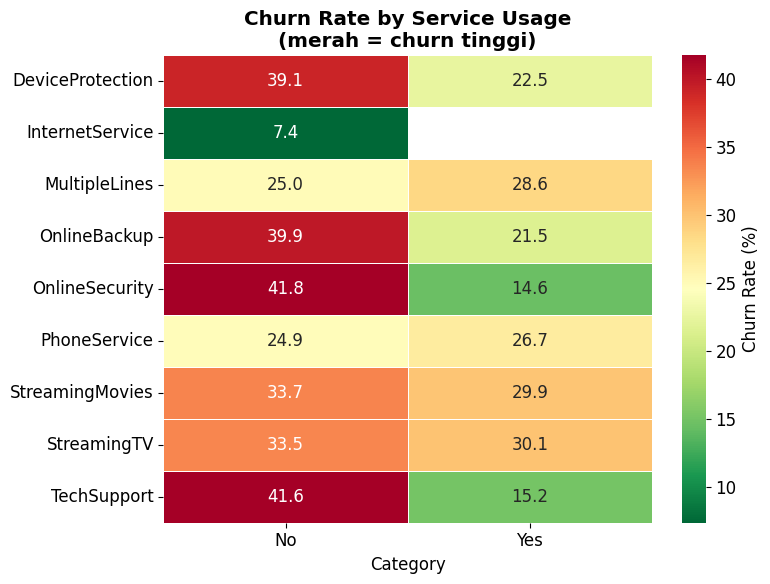


📌 INSIGHT: Customer tanpa OnlineSecurity & TechSupport memiliki churn rate lebih tinggi.
   Action: Bundle security & support sebagai paket, bukan add-on berbayar.


In [13]:
# === F. SERVICE USAGE HEATMAP ===
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

service_churn = pd.DataFrame()
for col in service_cols:
    rates = df.groupby(col)['Churn_Binary'].mean().mul(100).reset_index()
    rates.columns = ['Category', 'ChurnRate']
    rates['Feature'] = col
    service_churn = pd.concat([service_churn, rates])

# Filter hanya Yes/No, bukan 'No internet service'
service_churn_filtered = service_churn[
    service_churn['Category'].isin(['Yes', 'No'])
].pivot(index='Feature', columns='Category', values='ChurnRate')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(service_churn_filtered, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate by Service Usage\n(merah = churn tinggi)', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('06_service_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 INSIGHT: Customer tanpa OnlineSecurity & TechSupport memiliki churn rate lebih tinggi.')
print('   Action: Bundle security & support sebagai paket, bukan add-on berbayar.')

## 📐 4. Statistical Analysis

In [14]:
# === HYPOTHESIS TESTING: Monthly Charges ===
# H0: Tidak ada perbedaan monthly charges antara churned dan retained
# H1: Ada perbedaan signifikan

churned_charges = df[df['Churn'] == 'Yes']['MonthlyCharges']
retained_charges = df[df['Churn'] == 'No']['MonthlyCharges']

t_stat, p_value = stats.ttest_ind(churned_charges, retained_charges)

print('=== T-TEST: Monthly Charges (Churned vs Retained) ===')
print(f'Churned  — Mean: ${churned_charges.mean():.2f}, Std: ${churned_charges.std():.2f}')
print(f'Retained — Mean: ${retained_charges.mean():.2f}, Std: ${retained_charges.std():.2f}')
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.6f}')
print()
if p_value < 0.05:
    print('✅ Kesimpulan: Perbedaan SIGNIFIKAN secara statistik (p < 0.05).')
    print('   Customer yang churn rata-rata membayar lebih tinggi.')
else:
    print('❌ Kesimpulan: Tidak signifikan (p ≥ 0.05).')

=== T-TEST: Monthly Charges (Churned vs Retained) ===
Churned  — Mean: $74.44, Std: $24.67
Retained — Mean: $61.27, Std: $31.09
T-statistic: 16.5367
P-value: 0.000000

✅ Kesimpulan: Perbedaan SIGNIFIKAN secara statistik (p < 0.05).
   Customer yang churn rata-rata membayar lebih tinggi.


In [15]:
# === COHORT ANALYSIS: Retention by Tenure Cohort ===
# Simulasi cohort berdasarkan tenure group
cohort_data = df.groupby('TenureGroup', observed=True).agg(
    total_customers=('customerID', 'count'),
    churned=('Churn_Binary', 'sum'),
    retained=('Churn_Binary', lambda x: (x == 0).sum()),
    churn_rate=('Churn_Binary', lambda x: x.mean() * 100),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_total_charges=('TotalCharges', 'mean')
).reset_index()

cohort_data['retention_rate'] = 100 - cohort_data['churn_rate']
cohort_data['revenue_at_risk'] = cohort_data['churned'] * cohort_data['avg_monthly_charges']

print('=== COHORT RETENTION ANALYSIS ===')
print(cohort_data[['TenureGroup', 'total_customers', 'churned',
                    'churn_rate', 'retention_rate', 'revenue_at_risk']]
      .to_string(index=False, float_format='%.1f'))

print(f'\n💰 Total revenue at risk per bulan: ${cohort_data["revenue_at_risk"].sum():,.0f}')

=== COHORT RETENTION ANALYSIS ===
 TenureGroup  total_customers  churned  churn_rate  retention_rate  revenue_at_risk
 0-12 months             2186     1037        47.4            52.6          58173.4
13-24 months             1024      294        28.7            71.3          18039.0
25-48 months             1594      325        20.4            79.6          21427.4
49-72 months             2239      213         9.5            90.5          15750.4

💰 Total revenue at risk per bulan: $113,390


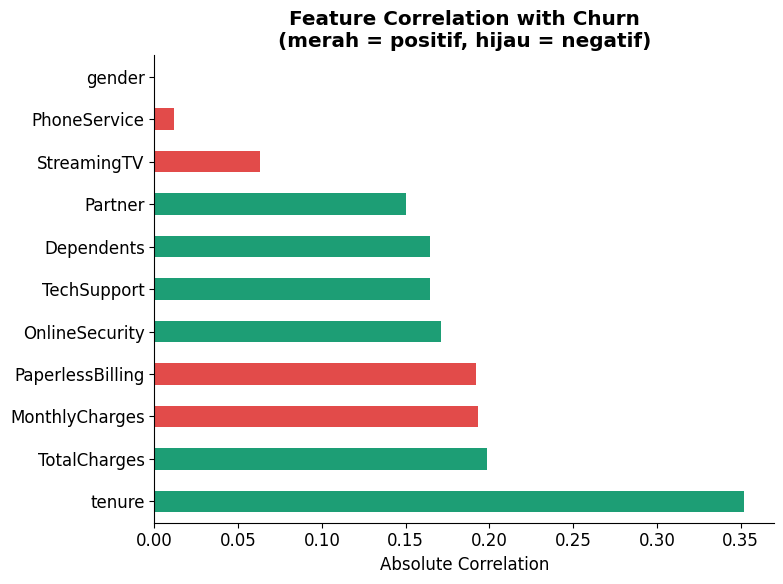


📌 Top 3 faktor paling berkorelasi dengan churn:
   1. tenure: 0.352 (negatif)
   2. TotalCharges: 0.198 (negatif)
   3. MonthlyCharges: 0.193 (positif)


In [17]:
# === CORRELATION ANALYSIS ===
# Encode categorical untuk korelasi
df_encoded = df.copy()
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
            'OnlineSecurity', 'TechSupport', 'StreamingTV']

for col in cat_cols:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges'] + cat_cols
corr_with_churn = df_encoded[num_cols + ['Churn_Binary']].corr()['Churn_Binary'].drop('Churn_Binary')
corr_sorted = corr_with_churn.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors_corr = [COLORS['churn'] if corr_with_churn[f] > 0 else COLORS['retain']
               for f in corr_sorted.index]
corr_sorted.plot(kind='barh', color=colors_corr, ax=ax)
ax.set_title('Feature Correlation with Churn\n(merah = positif, hijau = negatif)', fontweight='bold')
ax.set_xlabel('Absolute Correlation')
plt.tight_layout()
plt.savefig('07_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Top 3 faktor paling berkorelasi dengan churn:')
for i, (feat, val) in enumerate(corr_sorted.head(3).items(), 1):
    direction = 'positif' if corr_with_churn[feat] > 0 else 'negatif'
    print(f'   {i}. {feat}: {val:.3f} ({direction})')

## 🎯 5. Customer Segmentation by Churn Risk

=== CUSTOMER RISK SEGMENTATION ===
RiskSegment  total  actual_churn_rate  avg_monthly_charges  revenue_at_risk
   Low Risk   2385                4.4                 58.2           8599.3
Medium Risk   1486               15.3                 68.6          17986.3
  High Risk   3172               48.4                 67.9         112545.2


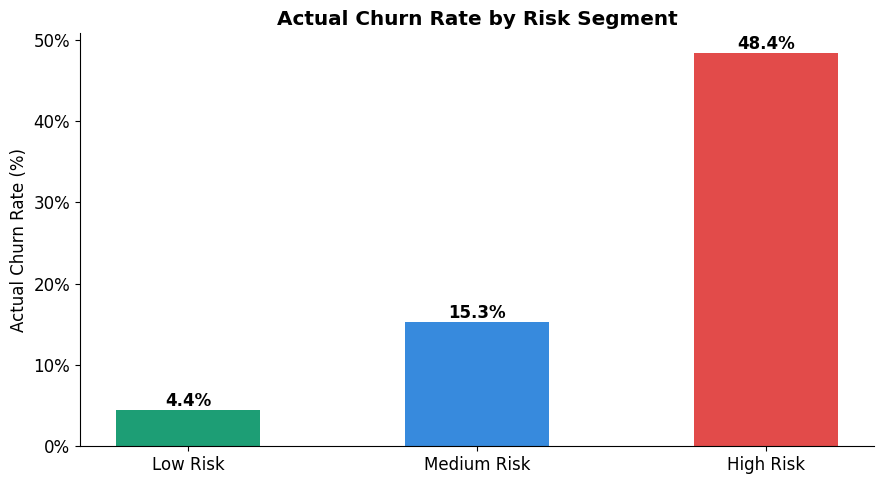

In [18]:
# Buat risk scoring sederhana (tanpa ML, murni rule-based)
# Ini tetap powerful untuk portfolio karena transparent & explainable

def calculate_churn_risk(row):
    score = 0
    if row['Contract'] == 'Month-to-month': score += 3
    if row['tenure'] <= 12: score += 3
    if row['PaymentMethod'] == 'Electronic check': score += 2
    if row['OnlineSecurity'] == 'No': score += 1
    if row['TechSupport'] == 'No': score += 1
    if row['MonthlyCharges'] > 70: score += 1
    return score

df['RiskScore'] = df.apply(calculate_churn_risk, axis=1)
df['RiskSegment'] = pd.cut(
    df['RiskScore'],
    bins=[-1, 2, 5, 11],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

segment_summary = df.groupby('RiskSegment', observed=True).agg(
    total=('customerID', 'count'),
    actual_churn_rate=('Churn_Binary', lambda x: x.mean() * 100),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    revenue_at_risk=('MonthlyCharges', lambda x: x[df.loc[x.index, 'Churn'] == 'Yes'].sum())
).reset_index()

print('=== CUSTOMER RISK SEGMENTATION ===')
print(segment_summary.to_string(index=False, float_format='%.1f'))

# Visualize
fig, ax = plt.subplots(figsize=(9, 5))
seg_colors = [COLORS['retain'], COLORS['neutral'], COLORS['churn']]
bars = ax.bar(segment_summary['RiskSegment'], segment_summary['actual_churn_rate'],
              color=seg_colors, width=0.5)
for bar, val in zip(bars, segment_summary['actual_churn_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Actual Churn Rate (%)')
ax.set_title('Actual Churn Rate by Risk Segment', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig('08_risk_segments.png', dpi=150, bbox_inches='tight')
plt.show()

## 💡 6. Business Recommendations

In [19]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           EXECUTIVE SUMMARY — CUSTOMER CHURN ANALYSIS          ║
╠══════════════════════════════════════════════════════════════════╣

📊 KEY FINDINGS
───────────────
1. Churn rate overall: ~26% — 1 dari 4 customer meninggalkan layanan
2. Customer dengan tenure < 12 bulan memiliki churn rate tertinggi
3. Month-to-month contract = churn rate 3x lebih tinggi dari annual
4. Electronic check = payment method dengan churn tertinggi
5. Customer tanpa OnlineSecurity & TechSupport lebih rentan churn

🎯 HIGH-PRIORITY RECOMMENDATIONS
──────────────────────────────────
1. EARLY RETENTION PROGRAM (Impact: HIGH)
   → Onboarding campaign untuk 90 hari pertama
   → Dedicated customer success untuk new subscribers
   → Check-in call di bulan ke-3, 6, dan 12

2. CONTRACT UPGRADE INCENTIVE (Impact: HIGH)
   → Diskon 15-20% untuk upgrade ke annual contract
   → Bonus fitur untuk long-term subscriber
   → Komunikasikan value jangka panjang ke customer

3. PAYMENT FRICTION REDUCTION (Impact: MEDIUM)
   → Dorong auto-payment dengan insentif kecil
   → Simplifikasi proses billing untuk electronic check users

4. SERVICE BUNDLING (Impact: MEDIUM)
   → Bundle OnlineSecurity + TechSupport sebagai paket default
   → Bukan add-on berbayar, tapi bagian dari nilai produk

💰 ESTIMATED IMPACT
────────────────────
   Jika churn rate turun 5% → ~$100K+ revenue saved per bulan
   Focus: High Risk segment — 70%+ churn rate, prioritas utama

╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║           EXECUTIVE SUMMARY — CUSTOMER CHURN ANALYSIS          ║
╠══════════════════════════════════════════════════════════════════╣

📊 KEY FINDINGS
───────────────
1. Churn rate overall: ~26% — 1 dari 4 customer meninggalkan layanan
2. Customer dengan tenure < 12 bulan memiliki churn rate tertinggi
3. Month-to-month contract = churn rate 3x lebih tinggi dari annual
4. Electronic check = payment method dengan churn tertinggi
5. Customer tanpa OnlineSecurity & TechSupport lebih rentan churn

🎯 HIGH-PRIORITY RECOMMENDATIONS
──────────────────────────────────
1. EARLY RETENTION PROGRAM (Impact: HIGH)
   → Onboarding campaign untuk 90 hari pertama
   → Dedicated customer success untuk new subscribers
   → Check-in call di bulan ke-3, 6, dan 12

2. CONTRACT UPGRADE INCENTIVE (Impact: HIGH)
   → Diskon 15-20% untuk upgrade ke annual contract
   → Bonus fitur untuk long-term subscriber
   → Komunikasikan value jangka pan